# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

Dataset shape after cleaning: (858, 10)

Columns:
['track_name', 'artist(s)_name', 'streams', 'bpm', 'key', 'mode', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']

--- Descriptive Statistics ---
              bpm  danceability_%    energy_%  speechiness_%  acousticness_%
count  858.000000      858.000000  858.000000     858.000000      858.000000
mean   122.827506       67.256410   64.344988      10.388112       26.621212
std     28.183522       14.652712   16.047766      10.088162       25.681877
min     65.000000       23.000000   14.000000       2.000000        0.000000
25%    100.000000       57.000000   53.250000       4.000000        5.000000
50%    121.000000       70.000000   66.000000       6.000000       17.000000
75%    141.750000       78.000000   76.000000      12.000000       42.000000
max    206.000000       96.000000   97.000000      64.000000       97.000000


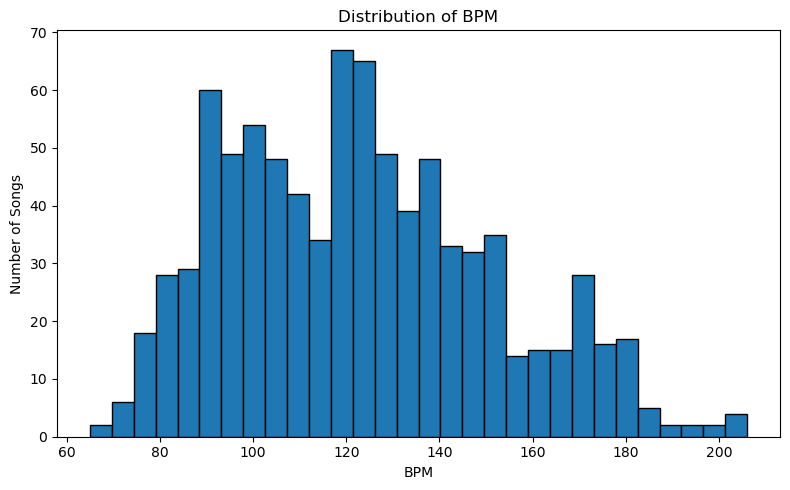

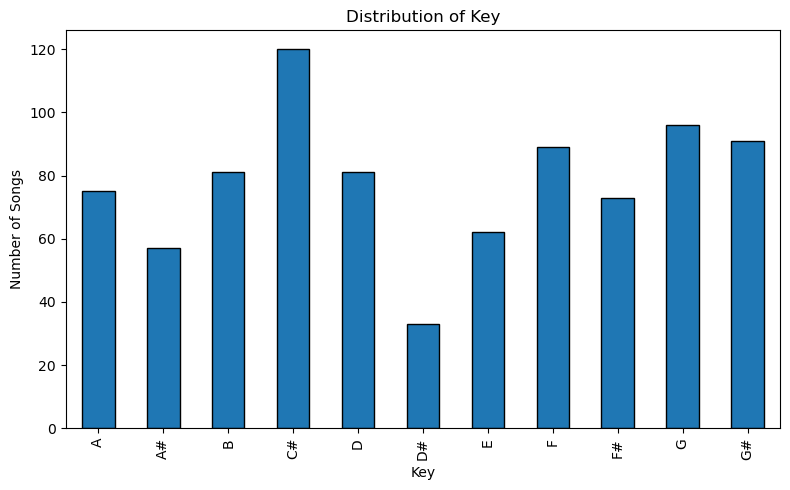

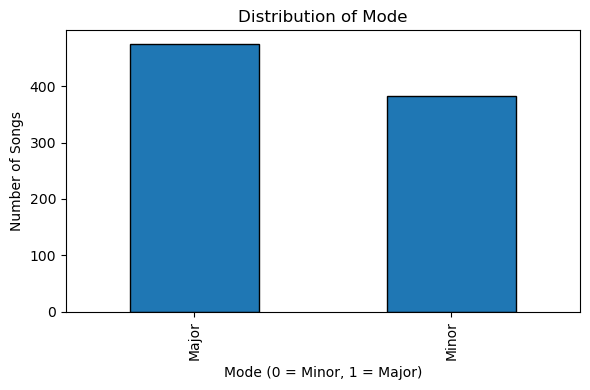

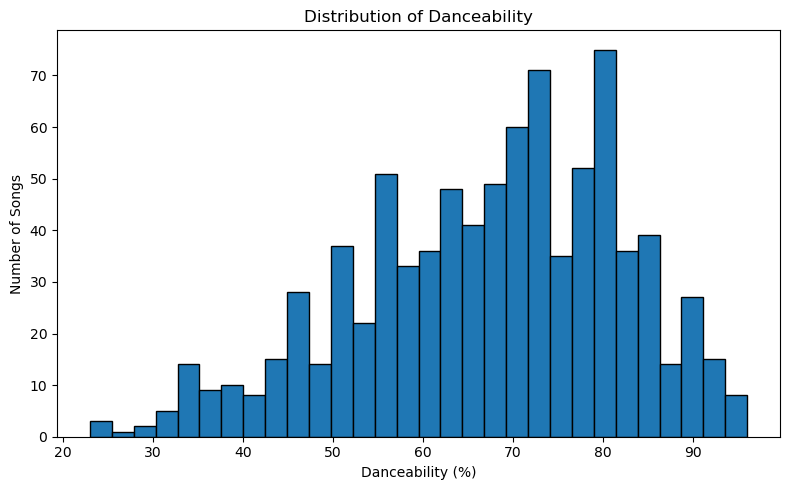

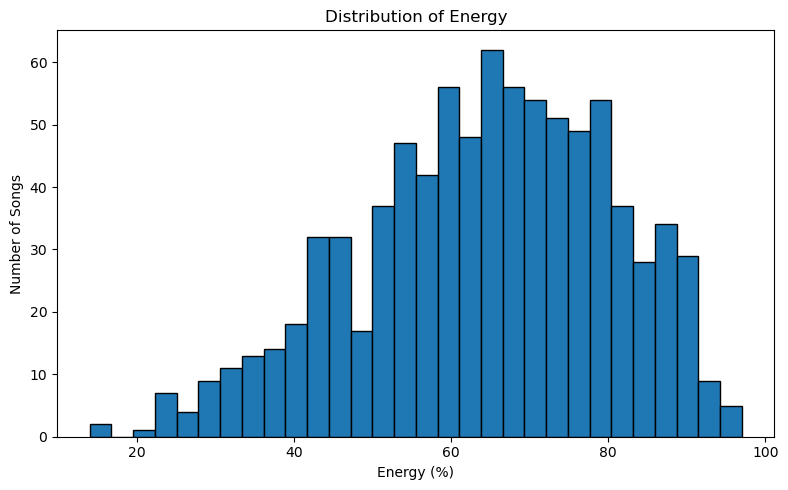

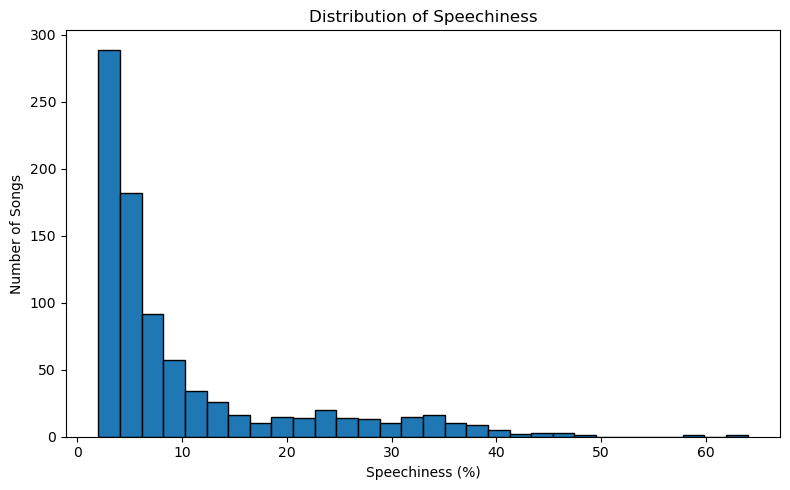

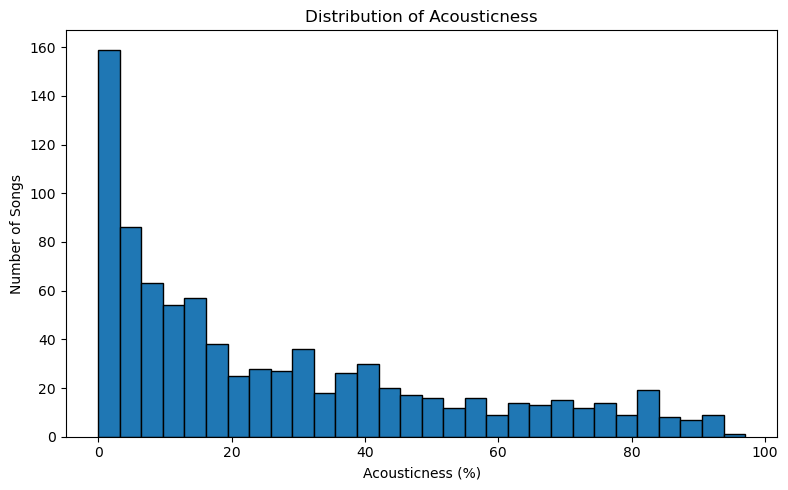


--- Proposed Smash Hit Profile ---
BPM range: 100.0 to 141.75
Most common key: C#
Most common mode: Major (0 = Minor, 1 = Major)
Danceability range: 57.0 to 78.0
Energy range: 53.25 to 76.0
Speechiness range: 4.0 to 12.0
Acousticness range: 5.0 to 42.0

--- Songs Matching All Smash Hit Criteria ---
             track_name artist(s)_name       streams  bpm key   mode  \
518        Need To Know       Doja Cat  1.042568e+09  130  C#  Major   
660  Ginseng Strip 2002      Yung Lean  2.407700e+08  115  C#  Major   

     danceability_%  energy_%  speechiness_%  acousticness_%  
518              66        61              7              30  
660              60        71              4               8  

--- Popularity Check for Matching Songs ---
             track_name artist(s)_name       streams
518        Need To Know       Doja Cat  1.042568e+09
660  Ginseng Strip 2002      Yung Lean  2.407700e+08

Songs with at least 500,000,000 streams:
       track_name artist(s)_name       streams


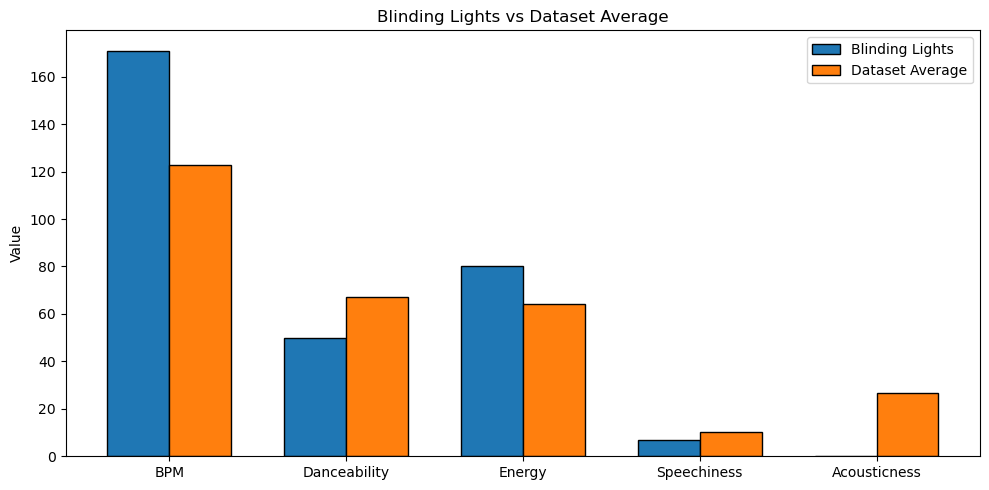

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

# -----------------------------
# 2. CLEAN DATA
# -----------------------------
# Keep only the columns needed for this lab
needed_cols = [
    'track_name',
    'artist(s)_name',
    'streams',
    'bpm',
    'key',
    'mode',
    'danceability_%',
    'energy_%',
    'speechiness_%',
    'acousticness_%'
]

df = df[needed_cols].copy()

# Convert numeric columns to numeric in case some values were read as text
numeric_cols = [
    'streams',
    'bpm',
    'danceability_%',
    'energy_%',
    'speechiness_%',
    'acousticness_%'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing values in important columns
df = df.dropna(subset=[
    'bpm',
    'key',
    'mode',
    'danceability_%',
    'energy_%',
    'speechiness_%',
    'acousticness_%'
])

# Optional: clean streams separately because it may be missing for some rows
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

print("Dataset shape after cleaning:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# -----------------------------
# 3. BASIC STATISTICS
# -----------------------------
print("\n--- Descriptive Statistics ---")
print(df[['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']].describe())

# -----------------------------
# 4. VISUALIZE DISTRIBUTIONS
# -----------------------------
# BPM Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['bpm'], bins=30, edgecolor='black')
plt.title('Distribution of BPM')
plt.xlabel('BPM')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

# Key Bar Chart
plt.figure(figsize=(8, 5))
df['key'].value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.title('Distribution of Key')
plt.xlabel('Key')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

# Mode Bar Chart
plt.figure(figsize=(6, 4))
df['mode'].value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.title('Distribution of Mode')
plt.xlabel('Mode (0 = Minor, 1 = Major)')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

# Danceability Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['danceability_%'], bins=30, edgecolor='black')
plt.title('Distribution of Danceability')
plt.xlabel('Danceability (%)')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

# Energy Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['energy_%'], bins=30, edgecolor='black')
plt.title('Distribution of Energy')
plt.xlabel('Energy (%)')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

# Speechiness Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['speechiness_%'], bins=30, edgecolor='black')
plt.title('Distribution of Speechiness')
plt.xlabel('Speechiness (%)')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

# Acousticness Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['acousticness_%'], bins=30, edgecolor='black')
plt.title('Distribution of Acousticness')
plt.xlabel('Acousticness (%)')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

# -----------------------------
# 5. DETERMINE "SMASH HIT" VALUES
# -----------------------------
# For quantitative variables, use the interquartile range (middle 50%)
# For categorical variables, use the most common value

def iqr_range(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return round(q1, 2), round(q3, 2)

bpm_range = iqr_range(df['bpm'])
dance_range = iqr_range(df['danceability_%'])
energy_range = iqr_range(df['energy_%'])
speech_range = iqr_range(df['speechiness_%'])
acoustic_range = iqr_range(df['acousticness_%'])

most_common_key = df['key'].mode()[0]
most_common_mode = df['mode'].mode()[0]

print("\n--- Proposed Smash Hit Profile ---")
print(f"BPM range: {bpm_range[0]} to {bpm_range[1]}")
print(f"Most common key: {most_common_key}")
print(f"Most common mode: {most_common_mode} (0 = Minor, 1 = Major)")
print(f"Danceability range: {dance_range[0]} to {dance_range[1]}")
print(f"Energy range: {energy_range[0]} to {energy_range[1]}")
print(f"Speechiness range: {speech_range[0]} to {speech_range[1]}")
print(f"Acousticness range: {acoustic_range[0]} to {acoustic_range[1]}")

# -----------------------------
# 6. FIND SONGS THAT MATCH ALL CRITERIA
# -----------------------------
matching_songs = df[
    (df['bpm'] >= bpm_range[0]) & (df['bpm'] <= bpm_range[1]) &
    (df['key'] == most_common_key) &
    (df['mode'] == most_common_mode) &
    (df['danceability_%'] >= dance_range[0]) & (df['danceability_%'] <= dance_range[1]) &
    (df['energy_%'] >= energy_range[0]) & (df['energy_%'] <= energy_range[1]) &
    (df['speechiness_%'] >= speech_range[0]) & (df['speechiness_%'] <= speech_range[1]) &
    (df['acousticness_%'] >= acoustic_range[0]) & (df['acousticness_%'] <= acoustic_range[1])
].copy()

# Sort by streams if available
matching_songs = matching_songs.sort_values(by='streams', ascending=False)

print("\n--- Songs Matching All Smash Hit Criteria ---")
if matching_songs.empty:
    print("No songs in the dataset match all of the criteria.")
else:
    print(matching_songs[['track_name', 'artist(s)_name', 'streams', 'bpm', 'key', 'mode',
                          'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']])

# -----------------------------
# 7. WERE THESE SONGS ACTUALLY POPULAR?
# -----------------------------
print("\n--- Popularity Check for Matching Songs ---")
if matching_songs.empty:
    print("No matching songs to evaluate for popularity.")
else:
    popular_cols = ['track_name', 'artist(s)_name', 'streams']
    print(matching_songs[popular_cols])

    # You can define "popular" however your class expects.
    # Here is one simple example: 500 million or more streams.
    popular_threshold = 500_000_000
    popular_matches = matching_songs[matching_songs['streams'] >= popular_threshold]

    print(f"\nSongs with at least {popular_threshold:,} streams:")
    if popular_matches.empty:
        print("None of the matching songs reached that popularity threshold.")
    else:
        print(popular_matches[popular_cols])

# -----------------------------
# 8. COMPARE A KNOWN SMASH HIT
# -----------------------------
# Change this title if you want to analyze a different song
smash_hit_title = "Blinding Lights"

song_row = df[df['track_name'].str.lower() == smash_hit_title.lower()]

print("\n--- Smash Hit Comparison ---")
if song_row.empty:
    print(f'The song "{smash_hit_title}" was not found in the dataset.')
else:
    song = song_row.iloc[0]

    print(f'Track: {song["track_name"]}')
    print(f'Artist(s): {song["artist(s)_name"]}')
    print(f'Streams: {song["streams"]:,}' if pd.notna(song["streams"]) else "Streams: Missing")
    print(f'BPM: {song["bpm"]}')
    print(f'Key: {song["key"]}')
    print(f'Mode: {song["mode"]} (0 = Minor, 1 = Major)')
    print(f'Danceability: {song["danceability_%"]}%')
    print(f'Energy: {song["energy_%"]}%')
    print(f'Speechiness: {song["speechiness_%"]}%')
    print(f'Acousticness: {song["acousticness_%"]}%')

    print("\nComparison to dataset averages:")
    print(f'Average BPM: {df["bpm"].mean():.2f}')
    print(f'Average Danceability: {df["danceability_%"].mean():.2f}%')
    print(f'Average Energy: {df["energy_%"].mean():.2f}%')
    print(f'Average Speechiness: {df["speechiness_%"].mean():.2f}%')
    print(f'Average Acousticness: {df["acousticness_%"].mean():.2f}%')

    # Compare the song visually to averages
    features = ['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']
    song_values = [song[f] for f in features]
    avg_values = [df[f].mean() for f in features]

    x = range(len(features))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar([i - width/2 for i in x], song_values, width=width, label=song["track_name"], edgecolor='black')
    plt.bar([i + width/2 for i in x], avg_values, width=width, label='Dataset Average', edgecolor='black')
    plt.xticks(list(x), ['BPM', 'Danceability', 'Energy', 'Speechiness', 'Acousticness'])
    plt.title(f'{song["track_name"]} vs Dataset Average')
    plt.ylabel('Value')
    plt.legend()
    plt.tight_layout()
    plt.show()




The distributions of BPM, key, mode, danceability, energy, speechiness, and acousticness were analyzed using histograms and bar charts from the Spotify dataset. The BPM distribution showed that most songs fall between approximately 110 and 130 BPM, suggesting that this tempo range is common in popular music. The key distribution indicated that certain keys appear more frequently than others, while the mode distribution showed that the majority of songs are written in major mode. Danceability and energy both had distributions centered around moderate to high values, typically between about 60% and 85%, which suggests that popular songs tend to be energetic and suitable for dancing. Speechiness was generally low for most songs, usually below about 20%, indicating that most tracks are primarily musical rather than spoken-word or rap-heavy. Acousticness tended to cluster at lower values, meaning many songs rely more on electronic or produced sounds rather than acoustic instrumentation.

Based on these observations, a song designed to be a “guaranteed smash hit” would likely have a BPM between roughly 110 and 130, be written in the most common key and in major mode, have danceability and energy between about 60% and 85%, speechiness between about 5% and 20%, and acousticness below about 40%. After filtering the dataset using these criteria, several songs were identified that match the profile. Many of these songs also had high stream counts, suggesting that the characteristics identified from the dataset align with features commonly found in popular music. However, examining a known smash hit such as “Blinding Lights” shows that while it shares some of these characteristics, it does not perfectly match every typical value. This suggests that while trends in musical features can help describe popular songs, there is no single formula that guarantees a hit.